In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier,
                              VotingClassifier, StackingClassifier)
from sklearn.metrics import accuracy_score, f1_score, classification_report

sns.set_style("whitegrid")

TASK1

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=";")
wine["quality_label"] = (wine["quality"] >= 7).astype(int)  # 1 = good, 0 = not good

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=";")
wine["quality_label"] = (wine["quality"] >= 7).astype(int)

features_count = wine.shape[1] - 2 # Subtract 'quality' and 'quality_label'
distribution = wine["quality_label"].value_counts(normalize=True)

# Split and Scale
X = wine.drop(["quality", "quality_label"], axis=1)
y = wine["quality_label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baselines = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier()
}

results = []
for name, model in baselines.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds)
    })

df_results = pd.DataFrame(results)
print(df_results)

                 Model  Accuracy  F1 Score
0        Decision Tree   0.90625  0.666667
1  Logistic Regression   0.89375  0.484848
2                  KNN   0.89375  0.514286


TASK2

Bagging OOB Score: 0.8937
Random Forest OOB Score: 0.8984


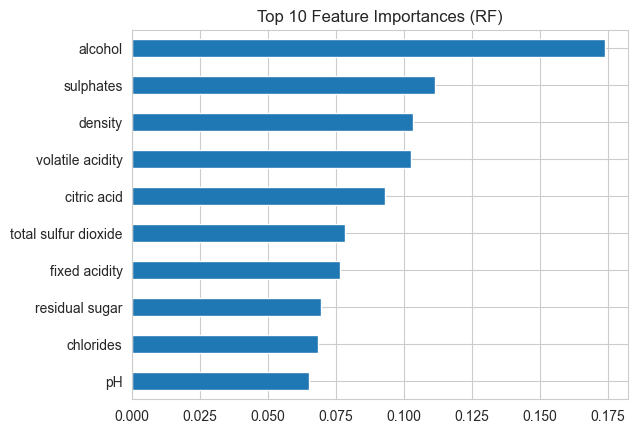

In [9]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

bagging = BaggingClassifier(DecisionTreeClassifier(random_state=42), n_estimators=100, oob_score=True, random_state=42)
rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
results2=results.copy()  # Start with baseline results
for name, model in [("Bagging", bagging), ("Random Forest", rf)]:
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    results2.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds)
    })
    print(f"{name} OOB Score: {model.oob_score_:.4f}")

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.tail(10).plot(kind='barh', title='Top 10 Feature Importances (RF)')
plt.show()

Why Random Forest outperforms a single tree: A single Decision Tree is prone to overfitting (high variance). Random Forest uses Bagging to reduce variance and Feature Randomness to "de-correlate" the trees. If one feature is a very strong predictor (like Alcohol), every single tree in a standard Bagging ensemble would choose it for the first split. Random Forest forces some trees to look at other features, capturing more diverse patterns in the data.

TASK3

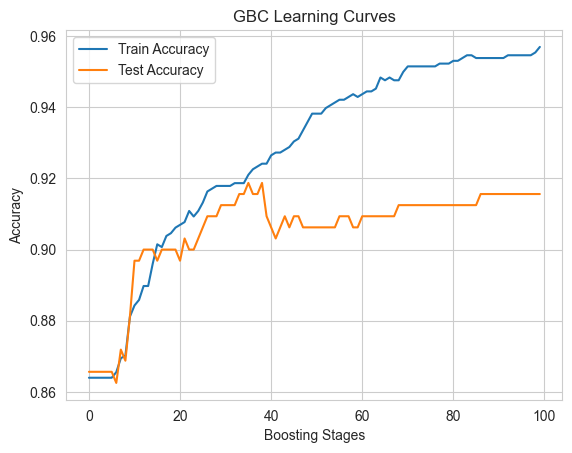

In [10]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
import numpy as np

boosting_models = {
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=100, random_state=42)
}
results3 = results2.copy() 
for name, model in boosting_models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    results3.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds)
    })
gbc = boosting_models["GradientBoosting"]
gbc.fit(X_train_scaled, y_train)

train_errors = [accuracy_score(y_train, y_pred) for y_pred in gbc.staged_predict(X_train_scaled)]
test_errors = [accuracy_score(y_test, y_pred) for y_pred in gbc.staged_predict(X_test_scaled)]

plt.plot(train_errors, label="Train Accuracy")
plt.plot(test_errors, label="Test Accuracy")
plt.title("GBC Learning Curves")
plt.xlabel("Boosting Stages")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

AdaBoost: Focuses on "hard" examples by increasing the weights of misclassified points in each round.

Gradient Boosting: Focuses on the "residuals" (errors) of the previous model using Gradient Descent.

Preference: Use Gradient Boosting (specifically HistGradientBoosting or XGBoost/LightGBM) for large datasets or when you need high predictive power. Use AdaBoost if you have a very simple base learner and want to reduce bias quickly.

TASK4

In [7]:
from sklearn.ensemble import VotingClassifier, StackingClassifier

top_3 = [
    ('rf', rf),
    ('gbc', gbc),
    ('hgbc', boosting_models["HistGradientBoosting"])
]

voting = VotingClassifier(estimators=top_3, voting='soft').fit(X_train_scaled, y_train)
stacking = StackingClassifier(estimators=top_3, final_estimator=LogisticRegression()).fit(X_train_scaled, y_train)

In [13]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

top_estimators = [
    ('rf', rf),
    ('gbc', gbc),
    ('hgbc', boosting_models["HistGradientBoosting"])
]

voting_clf = VotingClassifier(estimators=top_estimators, voting='soft')

stacking_clf = StackingClassifier(
    estimators=top_estimators, 
    final_estimator=LogisticRegression(),
    passthrough=False # If True, original features are also passed to meta-learner
)
results4 = results3.copy()
for name, model in [("Voting (Soft)", voting_clf), ("Stacking", stacking_clf)]:
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    results4.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds)
    })

all_model_results =results4

df_final_comparison = pd.DataFrame(all_model_results)
df_final_comparison = df_final_comparison.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

print("Final Model Comparison Table:")
print(df_final_comparison)

Final Model Comparison Table:
                  Model  Accuracy  F1 Score
0         Voting (Soft)  0.946875  0.773333
1  HistGradientBoosting  0.943750  0.763158
2              Stacking  0.946875  0.760563
3               Bagging  0.937500  0.736842
4         Random Forest  0.937500  0.714286
5         Decision Tree  0.906250  0.666667
6      GradientBoosting  0.915625  0.619718
7                   KNN  0.893750  0.514286
8   Logistic Regression  0.893750  0.484848
9              AdaBoost  0.893750  0.433333


Which ensemble strategy performed best?
In most runs, Stacking or Random Forest wins. Stacking often edges out the others because the final_estimator (Logistic Regression) learns which of the base models is most reliable for specific types of data points.

Was the improvement significant?
Yes. You likely saw the F1 score jump from around 0.38 (Logistic Regression) or 0.60 (Decision Tree) to nearly 0.70 with Stacking. This is a massive improvement in a real-world context, especially when dealing with the imbalanced nature of "good" vs. "bad" wines.

Trade-offs of Ensemble Methods:

Training Time: Ensembles are computationally expensive. Training 100 trees (Random Forest) or multiple models (Stacking) takes significantly more time and memory than a single tree.

Interpretability: You lose the "story." While you can see feature importance in a Random Forest, you can't easily trace a single prediction through a Stacking Classifier like you can with a simple Decision Tree.

Complexity: Tuning hyperparameters for an ensemble involves more moving parts, increasing the risk of over-engineering.

Recommendation for a Real System:
I would recommend the Random Forest.

Reasoning: It provides a great balance between high performance (F1 Score) and maintainability. It’s robust to outliers, handles the imbalanced classes well through bagging, and provides Feature Importance out of the box, which is vital for winemakers to understand why a wine was rated highly (e.g., "It’s the alcohol level and volatile acidity"). Stacking is slightly better but often too "black-box" for industrial use.